In [92]:
import pandas as pd
import numpy as np
import math
import random
from itertools import combinations
import scipy
from scipy.optimize import curve_fit
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [93]:
n=400
d=2
w = np.random.uniform()
a = 0

In [94]:
X = np.random.normal(size = (n, 1))

In [95]:
Y = w * X + a

In [96]:
Z = np.random.choice(range(2), size=(n, 1))

In [97]:
C = np.array([(1 if Y[i] >= 0 else 0) if Z[i] == 1 else (1 if Y[i] <= 0 else 0) for i in range(len(X))]).reshape(n, 1)

In [98]:
def solmap(y): return 1 if y[0] >= 0 else 0

In [99]:
def f(x, theta):
    return theta[0] + theta[1]*x

In [100]:
def pgcsubgradient(fx, y, h):
    return (solmap(fx + h * y) - solmap(fx - h * y)) / (2*h)

In [101]:
def derivtheta(f):
    out = np.ones(shape=(2, 1))
    out[1] = f
    return out

In [239]:
def stochastic_gradient_descent(X, Z, C, h = 1, lr=0.01, epochs=100):
    theta = np.random.randn(2, 1) # Initialize weights
    truelosses = []
    for epoch in tqdm(range(epochs)):
        # Shuffle data for true stochastic behavior
        indices = np.random.permutation(len(Z))
        trueloss = 0
        grad = 0
        for i in indices:
            xi, zi, ci = X[i], Z[i], C[i]
            trueloss += abs(solmap(Y[i]) - solmap(f(xi, theta))) / len(Z)

            # 2. Use the custom gradient to update weights
            # grad = (derivtheta(f(xi, theta)) * pgcsubgradient(f(xi, theta), thetadr(xi, zi, ci, nuisancef, Gram), h))
            grad += (derivtheta(f(xi, theta)) * pgcsubgradient(f(xi, theta), Y[i], h))

        theta += lr * grad/len(Z)
        truelosses.append(trueloss)
    return theta, truelosses

In [103]:
xi, zi, ci, yi = X[0], Z[0], C[0], Y[0]
theta = np.random.randn(2, 1)

In [104]:
derivtheta(f(xi, theta))

array([[1.        ],
       [2.57596261]])

  0%|          | 0/3000 [00:00<?, ?it/s]

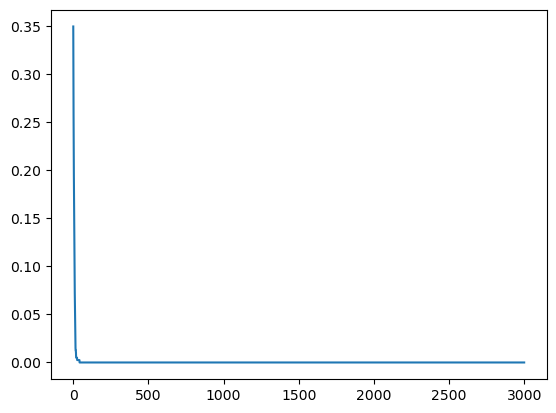

In [243]:
mytheta,truelosses = stochastic_gradient_descent(X, Z, C, h = 10, lr=5, epochs=3000)
plt.plot(truelosses)

In [241]:
mytheta

array([[-59.04706006],
       [-62.14160308]])

In [238]:
np.sum(f(X, mytheta) >= 0)

np.int64(363)

In [237]:
np.sum(Y >= 0)

np.int64(189)

In [118]:
mycost = np.sum([abs(solmap(Y[i]) - solmap(f(X[i], mytheta)))  for i in range(n)]) / n

In [119]:
mycost

np.float64(0.5275)